# Comparison Example: Place Cell Score

This notebook demonstrates the `PlaceCellScorer` class, which computes place cell metrics from 2D spatial ratemaps.

Two metrics are provided:

- **Spatial information score** (Skaggs et al., 1993): measures how much information (in bits per spike) a single spike conveys about the animal's location. Higher values indicate more spatially selective firing.

- **Place field detection**: identifies contiguous regions of elevated firing rate. Returns the number of fields, their sizes relative to the arena, and the peak firing rate.

We apply these metrics to:
1. Experimental recordings from the Hafting 2008 dataset, selecting cells with localized (place-cell-like) activity.
2. Spatial representations produced by the Stachenfeld 2018 (Successor Representation) model.

**References**
- Skaggs WE, McNaughton BL, Gothard KM, Markus EJ (1993). An information-theoretic approach to deciphering the hippocampal code. *Advances in Neural Information Processing Systems*, 5, 1030–1037.
- O'Keefe J, Dostrovsky J (1971). The hippocampus as a spatial map. *Brain Research*, 34(1):171–5.
- Hafting T et al. (2008). Hippocampus-independent path integration revealed through structural dissociations. *Nature*, 453, 1110–1113.

e## Spatial Information Score — Background

The spatial information score quantifies how selectively a neuron fires as a function of location. It is defined as (Skaggs et al., 1993):

$$I = \sum_{i} p_i \frac{\lambda_i}{\bar{\lambda}} \log_2 \frac{\lambda_i}{\bar{\lambda}}$$

where:

| Symbol | Meaning |
|--------|---------|
| $i$ | index over spatial bins |
| $p_i$ | occupancy probability of bin $i$ — fraction of total time the animal spent there |
| $\lambda_i$ | mean firing rate of the cell when the animal was in bin $i$ (spikes/s) |
| $\bar{\lambda} = \sum_i p_i \lambda_i$ | overall mean firing rate weighted by occupancy |

**Interpretation.** Each term $p_i \frac{\lambda_i}{\bar{\lambda}} \log_2 \frac{\lambda_i}{\bar{\lambda}}$ measures how much the firing rate in bin $i$ deviates from the global mean. A cell that fires uniformly everywhere has $\lambda_i = \bar{\lambda}$ for all $i$, making every term zero ($I = 0$ bits/spike). A cell with a tight place field concentrates its spikes in a small region where $\lambda_i \gg \bar{\lambda}$, yielding large positive contributions and thus a high $I$.

You can also think of this as a KL divergence between P(location|spikes) and P(location), basically asking how much different is the distribution of spikes given a position compared to the overall distribution of positions. The more the cell's firing is concentrated in specific locations, the higher the spatial information score.

To see this just note that the posterior probability of a spike happening at a given location is
$Q_{i} = \frac{p_i \lambda_i}{\bar{\lambda}}$. Then the KL divergence for a uniform prior $P = p_{i}$ is

\begin{align*}
D(Q|P) & = \sum_{i}Q_{i}\log\left(\frac{Q_{i}}{P{i}}\right), \\
& = \sum_{i} \frac{p_i \lambda_i}{\bar{\lambda}} \log\left(\frac{\frac{p_i \lambda_i}{\bar{\lambda}}}{p_i}\right), \\
& = \sum_{i} p_i \frac{\lambda_i}{\bar{\lambda}} \log\left(\frac{\lambda_i}{\bar{\lambda}}\right).
\end{align*}

Typical values: place cells range from ~1–4 bits/spike; grid cells and spatially untuned cells tend to score lower. When no occupancy map is provided, uniform occupancy ($p_i = 1/N_\text{visited}$) is assumed.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from neuralplayground.agents import Weber2018
from neuralplayground.arenas import Hafting2008
from neuralplayground.comparison import PlaceCellScorer

## 1. Experimental Data — Hafting 2008

The Hafting 2008 dataset contains single-unit recordings from medial entorhinal cortex. While most recorded cells show grid-cell-like periodicity, some exhibit more localised, place-cell-like activity (few firing fields, high spatial information). We score all 11 recordings and highlight the most place-cell-like ones.

In [15]:
env = Hafting2008(time_step_size=1, agent_step_size=None)

# Score all recordings and select the three most place-cell-like
# (fewest fields and highest spatial information)
all_scores = {}
for rec_idx in range(len(env.recording_list)):
    r_out_im, x_bin, y_bin = env.recording_tetr(recording_index=rec_idx)
    scorer = PlaceCellScorer(nbins=x_bin.size - 1)
    all_scores[rec_idx] = scorer.get_scores(r_out_im)
    print(
        f"rec {rec_idx:2d}: n_fields={all_scores[rec_idx]['n_fields']:2d}, "
        f"spatial_info={all_scores[rec_idx]['spatial_information']:.3f} bits/spike"
    )

# Pick recordings with the fewest fields as most place-cell-like
place_cell_indices = sorted(all_scores, key=lambda i: all_scores[i]["n_fields"])[:3]
print(f"\nMost place-cell-like recordings: {place_cell_indices}")

rec  0: n_fields= 4, spatial_info=1.547 bits/spike
rec  1: n_fields= 2, spatial_info=2.014 bits/spike
rec  2: n_fields= 5, spatial_info=1.306 bits/spike
rec  3: n_fields= 2, spatial_info=1.805 bits/spike
rec  4: n_fields= 2, spatial_info=1.921 bits/spike
rec  5: n_fields= 4, spatial_info=1.624 bits/spike
rec  6: n_fields= 7, spatial_info=1.008 bits/spike
rec  7: n_fields= 2, spatial_info=1.510 bits/spike
rec  8: n_fields= 4, spatial_info=1.606 bits/spike
rec  9: n_fields= 4, spatial_info=1.265 bits/spike
rec 10: n_fields= 5, spatial_info=1.302 bits/spike

Most place-cell-like recordings: [1, 3, 4]


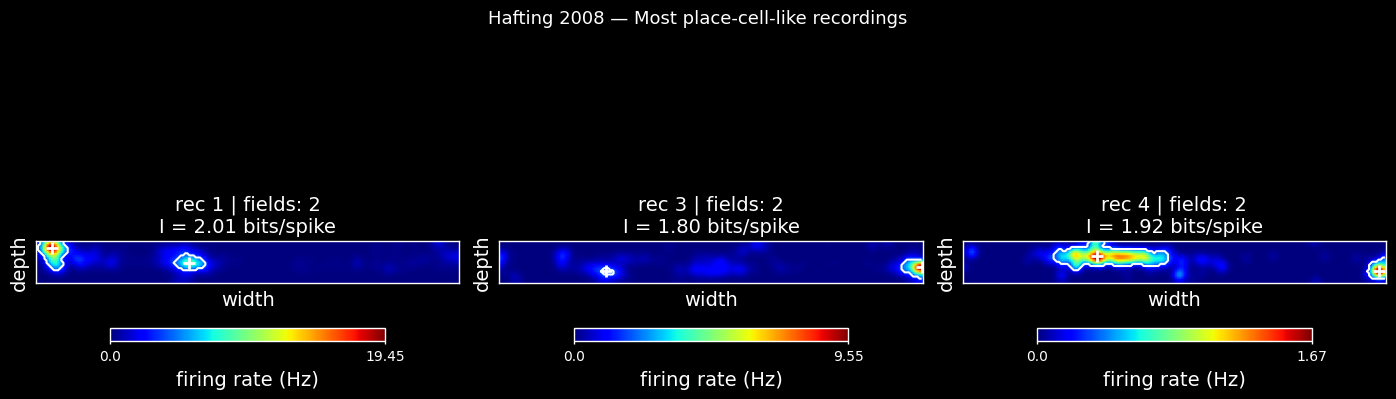

In [16]:
# Plot the most place-cell-like recordings
fig, axes = plt.subplots(1, len(place_cell_indices), figsize=(14, 4))
fig.suptitle("Hafting 2008 — Most place-cell-like recordings", fontsize=13)

for ax, rec_idx in zip(axes, place_cell_indices):
    r_out_im, x_bin, y_bin = env.recording_tetr(recording_index=rec_idx)
    scorer = PlaceCellScorer(nbins=x_bin.size - 1)
    scores = scorer.get_scores(r_out_im)
    scorer.plot_place_fields(
        r_out_im,
        ax=ax,
        title=(
            f"rec {rec_idx} | fields: {scores['n_fields']}\n"
            f"I = {scores['spatial_information']:.2f} bits/spike"
        ),
    )

plt.tight_layout()
plt.show()

### Full score dictionary

The `get_scores` method returns a dictionary with all computed metrics for a single ratemap.

In [17]:
r_out_im, x_bin, y_bin = env.recording_tetr(recording_index=place_cell_indices[0])
scorer = PlaceCellScorer(nbins=x_bin.size - 1)
scores = scorer.get_scores(r_out_im)

for key, value in scores.items():
    if key != "field_labels":  # skip the label array for readability
        print(f"{key}: {value}")

spatial_information: 2.0139681912077756
n_fields: 2
field_sizes_bins: [134, 81]
field_size_mean_fraction: 0.026875
peak_firing_rate: 19.446632309845434
mean_firing_rate: 0.8100000000000002
peak_coords: [(np.int64(3), np.int64(7)), (np.int64(10), np.int64(72))]


## 2. Agent Output — Weber 2018

Weber and Sprekeler (2018) show that the output neuron firing pattern depends on the relative
width of excitatory and inhibitory input fields. When inhibitory inputs are much broader than
excitatory ones (Figure 1d of the paper), the output neuron learns a **single localized place
field**.

Here we use the Hafting 2008 arena with the recorded behavioral trajectory to drive the agent,
and apply `PlaceCellScorer` to the learned output ratemap.

In [18]:
# Use the Hafting2008 arena replaying the recorded behavioral trajectory
env_weber = Hafting2008(use_behavioral_data=True, recording_index=0)

# Weber 2018 parameters for place-cell-like output (Figure 1d equivalent, 2D).
# sigma_inh >> sigma_exc gives smooth/broad inhibitory inputs -> single place field.
agent_weber = Weber2018(
    model_name='place_cell_weber',
    etaexc=2e-4,
    etainh=8e-4,
    sigma_exc=np.array([0.05, 0.05]),  # narrow excitatory fields
    sigma_inh=np.array([0.3, 0.3]),    # broad inhibitory -> place cell regime (Fig 1d)
    Ne=1000,
    Ni=100,
    Nef=1,
    Nif=1,
    alpha_e=1,
    alpha_i=1,
    we_init=1.0,
    wi_init=1.5,
    ro=1,
    room_width=env_weber.room_width,
    room_depth=env_weber.room_depth,
)

100%|██████████| 1000/1000 [00:00<00:00, 14870.36it/s]


  0%|          | 0/20000 [00:00<?, ?it/s]

/Users/rodrigo/Projects/others/NeuralPlayground/neuralplayground/agents/weber_2018.py:326: RuntimeWarning: divide by zero encountered in matmul
  r_out = self.we.T @ exc_rates - self.wi.T @ inh_rates
/Users/rodrigo/Projects/others/NeuralPlayground/neuralplayground/agents/weber_2018.py:326: RuntimeWarning: overflow encountered in matmul
  r_out = self.we.T @ exc_rates - self.wi.T @ inh_rates
/Users/rodrigo/Projects/others/NeuralPlayground/neuralplayground/agents/weber_2018.py:326: RuntimeWarning: invalid value encountered in matmul
  r_out = self.we.T @ exc_rates - self.wi.T @ inh_rates
/Users/rodrigo/Projects/others/NeuralPlayground/neuralplayground/agents/weber_2018.py:371: RuntimeWarning: divide by zero encountered in matmul
  r_out = self.we.T @ self.exc_cell_list - self.wi.T @ self.inh_cell_list
/Users/rodrigo/Projects/others/NeuralPlayground/neuralplayground/agents/weber_2018.py:371: RuntimeWarning: overflow encountered in matmul
  r_out = self.we.T @ self.exc_cell_list - self.wi.

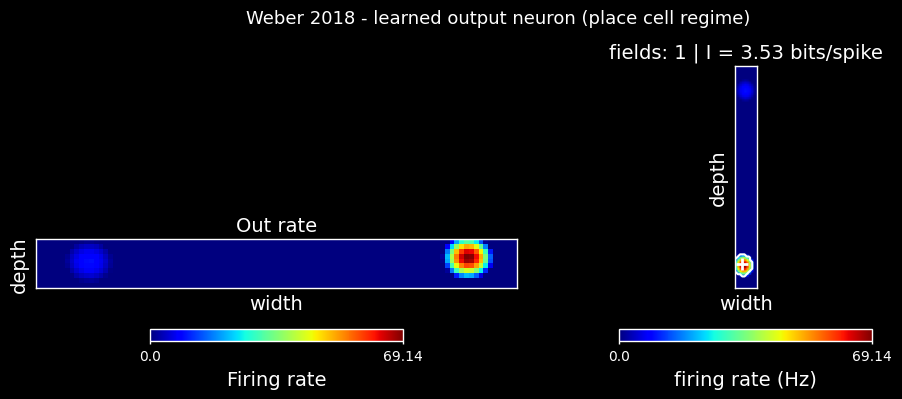

Weber 2018 place cell scores:
  spatial_information: 3.533583864229213
  n_fields: 1
  field_sizes_bins: [62]
  field_size_mean_fraction: 0.062
  peak_firing_rate: 69.14365553456767
  mean_firing_rate: 2.8601295980171835
  peak_coords: [(np.int64(89), np.int64(3))]


In [19]:
# Run the agent along the recorded Hafting trajectory
n_steps = 20000
obs, state = env_weber.reset()
for i in tqdm(range(n_steps)):
    obs = obs[:2]
    action = agent_weber.act(obs)
    agent_weber.update()
    obs, state, reward = env_weber.step(action)

# Show the learned output ratemap and place cell scores
r_out_im = agent_weber.get_rate_map_matrix()
scorer_weber = PlaceCellScorer(nbins=agent_weber.resolution_width)
scores_weber = scorer_weber.get_scores(r_out_im)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Weber 2018 - learned output neuron (place cell regime)', fontsize=13)
agent_weber.plot_rate_map(ax=axes[0])
scorer_weber.plot_place_fields(
    r_out_im,
    ax=axes[1],
    title='fields: {} | I = {:.2f} bits/spike'.format(
        scores_weber['n_fields'], scores_weber['spatial_information']
    ),
)
plt.tight_layout()
plt.show()

print('Weber 2018 place cell scores:')
for key, value in scores_weber.items():
    if key != 'field_labels':
        print('  {}: {}'.format(key, value))